# TP1 - Découverte et Valeurs Manquantes Simples

**Difficulté:** Débutant  
**Dataset:** ecommerce_simple.csv  
**Description:** Introduction au nettoyage avec gestion basique des valeurs manquantes

---


## Imports des Bibliothèques


In [4]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [5]:
# Afficher les informations de base

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/data_cleaning_project/ecommerce_simple.csv'
df = pd.read_csv(file_path)


print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

Mounted at /content/drive
📏 Dimensions: 500 lignes × 8 colonnes
 Taille mémoire: 0.13 MB




,order_id,customer_id,product,price,quantity,category,order_date,shipping_address
0,1,8270,Laptop,1463.85,2,Accessories,2023-01-01 00:00:00,NaN
1,2,1860,Phone,761.59,3,Electronics,2023-01-01 01:00:00,"4 Main St, City"
2,3,6390,Phone,1098.20,4,Electronics,2023-01-01 02:00:00,NaN
3,4,6191,Headphones,1240.25,4,Accessories,2023-01-01 03:00:00,NaN
4,5,6734,Laptop,1091.76,3,Electronics,2023-01-01 04:00:00,NaN




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product           500 non-null    object 
 3   price             455 non-null    float64
 4   quantity          500 non-null    int64  
 5   category          500 non-null    object 
 6   order_date        500 non-null    object 
 7   shipping_address  234 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 31.4+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

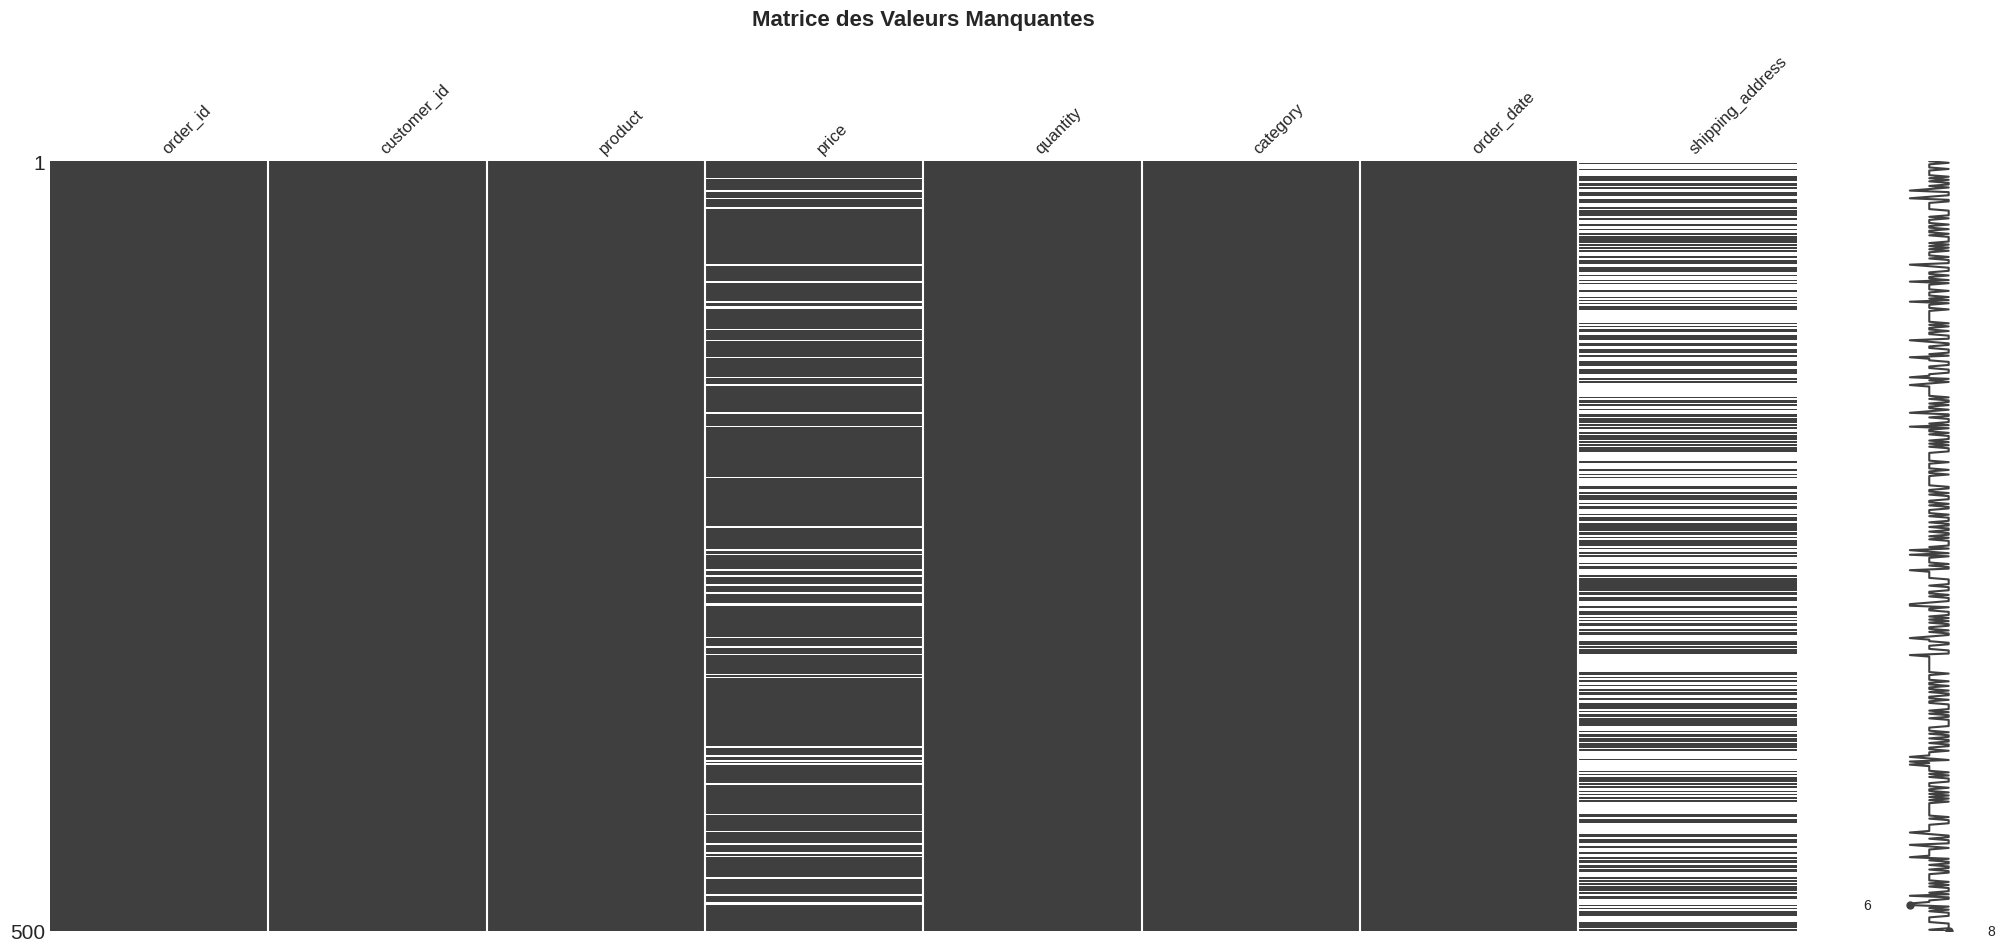


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing
shipping_address,266,53.20
price,45,9.00


In [18]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])



## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de lignes et colonnes contient le dataset ?
2. Quelles colonnes contiennent des valeurs manquantes ?
3. Quel est le pourcentage de valeurs manquantes par colonne ?
4. Quelle colonne a le plus de valeurs manquantes ?
5. Y a-t-il des colonnes avec plus de 50% de valeurs manquantes ?
6. Combien de lignes sont complètes (sans aucune valeur manquante) ?
7. Quelle est la moyenne de la colonne 'price' ?
8. Combien de catégories uniques dans la colonne 'category' ?
9. Y a-t-il des valeurs négatives dans les colonnes numériques ?
10. Quelle est la date la plus ancienne dans le dataset ?


In [42]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
#print(df.describe())
print(f"1. Nombre de lignes et colonnes dans le dataset: {df.shape[1]}")
print(f"2. Les colonnes qui contiennet de valeurs manquantes sont: {df.columns[df.isna().any()].tolist()}")
print(f"3. Pourcentage de valeurs manquantes par colonne: {df.isna().mean()*100}")
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici

1. Nombre de lignes et colonnes dans le dataset: 8
2. Les colonnes qui contiennet de valeurs manquantes sont: ['price', 'shipping_address']
3. Pourcentage de valeurs manquantes par colonne: order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64
Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Importer et afficher les 5 premières lignes du dataset
### Étape 2: Afficher les informations générales (df.info())
### Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
### Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
### Étape 5: Remplir les valeurs manquantes numériques avec la médiane
### Étape 6: Remplir les valeurs manquantes catégorielles avec le mode
### Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
### Étape 8: Afficher un résumé des transformations effectuées


In [8]:
# ========================================
# Étape 1: Importer et afficher les 5 premières lignes du dataset
# ========================================

# TODO: Écrivez votre code ici
print(f"Les 5 premières lignes du datatset: {df.head(5)}")

# Vérification
print(f"Étape 1 complétée")

Les 5 premières lignes du datatset:    order_id  customer_id     product   price  quantity     category  \
0         1         8270      Laptop 1463.85         2  Accessories   
1         2         1860       Phone  761.59         3  Electronics   
2         3         6390       Phone 1098.20         4  Electronics   
3         4         6191  Headphones 1240.25         4  Accessories   
4         5         6734      Laptop 1091.76         3  Electronics   

            order_date shipping_address  
0  2023-01-01 00:00:00              NaN  
1  2023-01-01 01:00:00  4 Main St, City  
2  2023-01-01 02:00:00              NaN  
3  2023-01-01 03:00:00              NaN  
4  2023-01-01 04:00:00              NaN  
Étape 1 complétée


In [9]:
# ========================================
# Étape 2: Afficher les informations générales (df.info())
# ========================================

# TODO: Écrivez votre code ici
print(f"Informatios générales: {df.info()}")

# Vérification
print(f"Étape 2 complétée")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product           500 non-null    object 
 3   price             455 non-null    float64
 4   quantity          500 non-null    int64  
 5   category          500 non-null    object 
 6   order_date        500 non-null    object 
 7   shipping_address  234 non-null    object 
dtypes: float64(1), int64(3), object(4)
memory usage: 31.4+ KB
Informatios générales: None
Étape 2 complétée


In [25]:
# ========================================
# Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
# ========================================

# TODO: Écrivez votre code ici
print(f"Pourcentage de valeurs manquantes par colonne:")
print(df.isna().mean()*100)
# Vérification
print(f"Étape 3 complétée")

Pourcentage de valeurs manquantes par colonne:
order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64
Étape 3 complétée


In [47]:
# ========================================
# Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
# ========================================

# TODO: Écrivez votre code ici
print("Colonnes restées finale après supprimmage de colonne de valeurs manquantes >70%")

df_clean = df.dropna(axis=1, thresh=(len(df)*.7), inplace=False)
print(df_clean.columns)

# Vérification
print(f"Étape 4 complétée")

Colonnes restées finale après supprimmage de colonne de valeurs manquantes >70%
Index(['order_id', 'customer_id', 'product', 'price', 'quantity', 'category',
       'order_date'],
      dtype='object')
Étape 4 complétée


In [66]:
# ========================================
# Étape 5: Remplir les valeurs manquantes numériques avec la médiane
# ========================================

# TODO: Écrivez votre code ici
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
print(f"Total nombre de valeurs après remplacement de valeurs manquantes:")
print(df_clean.size) #(lignes * colonnes)
# Vérification
print(f"Étape 5 complétée")

Total nombre de valeurs après remplacement de valeurs manquantes:
3500
Étape 5 complétée


In [67]:
# ========================================
# Étape 6: Remplir les valeurs manquantes catégorielles avec le mode
# ========================================

# TODO: Écrivez votre code ici
df_clean.fillna(df_clean.mode(numeric_only=True), inplace=True)

# Vérification
print(f"Étape 6 complétée")

Étape 6 complétée


In [57]:
# ========================================
# Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
# ========================================

# TODO: Écrivez votre code ici
print(df_clean.isnull().sum())

# Vérification
print(f"Étape 7 complétée")

order_id       0
customer_id    0
product        0
price          0
quantity       0
category       0
order_date     0
dtype: int64
Étape 7 complétée


In [61]:
# ========================================
# Étape 8: Afficher un résumé des transformations effectuées
# ========================================

# TODO: Écrivez votre code ici
def audit_data(df):
  print(f"Les 5 premières lignes du datatset: {df.head(3)}")
  print(f"Informatios générales: {df.info()}")

  percent_missing_column = df.isnull().mean()*100
  missing_summary = pd.DataFrame({'column_name': df.columns, 'percent_missing': percent_missing_column})
  print(f"Percentage_manquant_colonne: {missing_summary}")

  df_clean = df.dropna(axis=1, thresh=(len(df)*.7), inplace=False)
  print(f"Data sans valuer manquantes: {df_clean.head(3)}")

  df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
  df_clean.fillna(df_clean.mode(numeric_only=True), inplace=True)
  print(df_clean.isnull().sum())

audit_data(df_clean)


# Vérification
print(f"Étape 8 complétée")

Les 5 premières lignes du datatset:    order_id  customer_id product   price  quantity     category  \
0         1         8270  Laptop 1463.85         2  Accessories   
1         2         1860   Phone  761.59         3  Electronics   
2         3         6390   Phone 1098.20         4  Electronics   

            order_date  
0  2023-01-01 00:00:00  
1  2023-01-01 01:00:00  
2  2023-01-01 02:00:00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     500 non-null    int64  
 1   customer_id  500 non-null    int64  
 2   product      500 non-null    object 
 3   price        500 non-null    float64
 4   quantity     500 non-null    int64  
 5   category     500 non-null    object 
 6   order_date   500 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 27.5+ KB
Informatios générales: None
Percentage_manquant_co

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [70]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df_clean.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': len(df)-len(df_clean),
    'Colonnes_supprimées': df.shape[1] - df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.size-df_clean.size,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (500, 7)
Dimensions_finales...................... (500, 7)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 1
Valeurs_manquantes_traitées............. 500
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
